# Final Python Notebook 2: Classification Models
**Author:** Gihan Pasindu

**Reviewer:** Pasan Hirunaka


### Leveraged from Code Reuse Session 2: Import Libraries and Load Dataset
Loading the classification-specific CSV dataset curated in Notebook 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

# load data
df_status = pd.read_csv("loan_approval_status_data.csv")

# final check for missing values
print("Missing values in dataset:")
print(df_status.isnull().sum())

df_status.head()


Missing values in dataset:
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
dtype: int64


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


### Leveraged from Code Reuse Session 2: Modelling (Train-Test Split)
Data split into training and testing partitions using class stratification to maintain ratio representation.


In [2]:
# X and y
X = df_status.drop(['loan_approval_status'], axis=1)
y = df_status['loan_approval_status']

# 80/20 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("features:", list(X.columns))

# Verification of stratification for report evidence
print("\nTrain dataset target distribution:")
print(y_train.value_counts())
print("\nTesting dataset target distribution:")
print(y_test.value_counts())


X_train shape: (46916, 10)
features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Train dataset target distribution:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

Testing dataset target distribution:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


### Leveraged from Code Reuse Session 2: Building Models (NB, LR, KNN)
Three base models (Logistic Regression, Naive Bayes, and KNN) are constructed and trained.


In [3]:
# 1. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# 2. Logistic Regression 
lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 3. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("Model training execution complete.")


C:\Users\Gihan Pasindu\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model training execution complete.


### Leveraged from Code Reuse Session 2: Evaluating Classification Models
Models evaluated using confusion matrices and ROC curves for visual diagnostics.



--- Report for Naive Bayes ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     10059
           1       0.67      0.34      0.45      1670

    accuracy                           0.88     11729
   macro avg       0.78      0.66      0.69     11729
weighted avg       0.87      0.88      0.87     11729

Naive Bayes Confusion Matrix Array:
[[9771  288]
 [1097  573]]


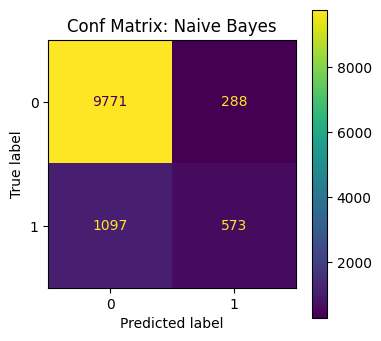

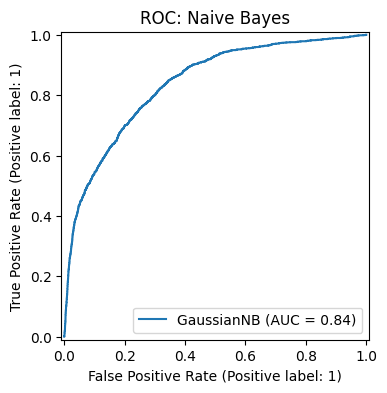


--- Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.94     10059
           1       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

Logistic Regression Confusion Matrix Array:
[[9807  252]
 [1035  635]]


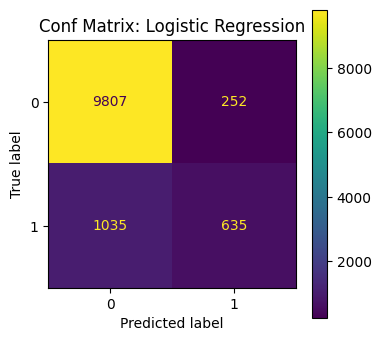

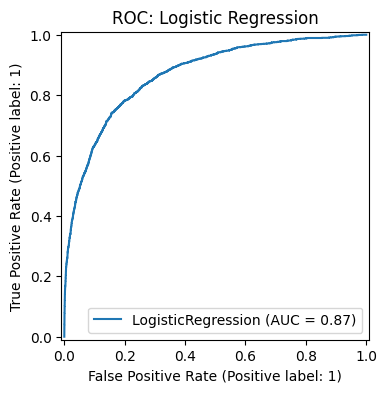


--- Report for KNN ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10059
           1       0.67      0.50      0.57      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.73      0.76     11729
weighted avg       0.88      0.89      0.89     11729

KNN Confusion Matrix Array:
[[9644  415]
 [ 834  836]]


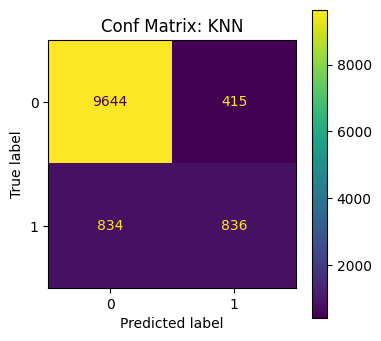

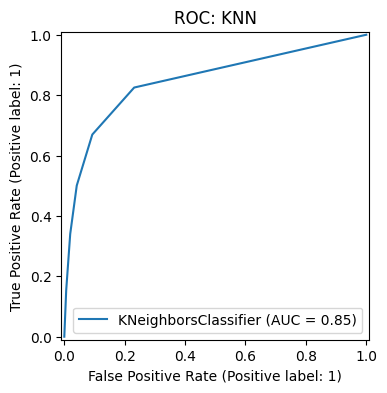

In [4]:
def eval_model(model, name, y_pred):
    print(f"\n--- Report for {name} ---")
    print(classification_report(y_test, y_pred))
    
    # raw confusion matrix array for report evidence
    print(f"{name} Confusion Matrix Array:")
    print(confusion_matrix(y_test, y_pred))
    
    # conf matrix graph
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, values_format='.0f')
    plt.title(f"Conf Matrix: {name}")
    plt.show()
    
    # roc curve
    fig, ax = plt.subplots(figsize=(4, 4))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    plt.title(f"ROC: {name}")
    plt.show()

eval_model(nb_model, "Naive Bayes", y_pred_nb)
eval_model(lr_model, "Logistic Regression", y_pred_lr)
eval_model(knn_model, "KNN", y_pred_knn)


### Leveraged from Code Reuse Session 2: Hyperparameters Tuning
KNN identified as the most suitable candidate. GridSearchCV deployed to optimise its specific hyperparameters to increase recall metric.


Optimal parameters acquired: {'n_neighbors': 7, 'weights': 'distance'}

--- Report for Optimised KNN ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10059
           1       0.65      0.51      0.57      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.73      0.75     11729
weighted avg       0.88      0.89      0.89     11729

Optimised KNN Confusion Matrix Array:
[[9609  450]
 [ 826  844]]


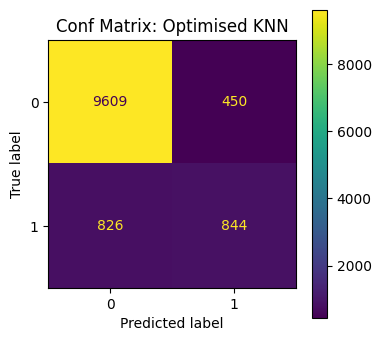

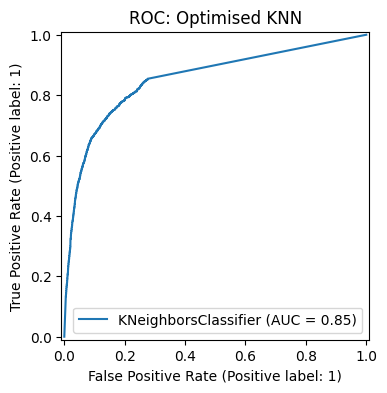

In [5]:
from sklearn.model_selection import GridSearchCV

# specific params to tune for knn
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# run grid search cross validation
knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
knn_gscv.fit(X_train, y_train)

print("Optimal parameters acquired:", knn_gscv.best_params_)

# generate predictions using tuned model
knn_best = knn_gscv.best_estimator_
y_pred_knn_best = knn_best.predict(X_test)

# secondary performance evaluation
eval_model(knn_best, "Optimised KNN", y_pred_knn_best)
